# 03 Feature Engineering and Supervised Modeling

**Project:** STAT GR5243 Project 4: End-to-End Machine Learning  
**Topic:** Predicting High-Occupancy Airbnb Listings in New York City

This notebook builds supervised classification models to predict whether an Airbnb listing is high-occupancy.

## 1. Import Libraries and Load Data
Run this notebook from the `notebooks/` folder.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
)
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report
)
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
import shap

processed_path = Path("../data/processed")
fig_path = Path("../figures")
fig_path.mkdir(parents=True, exist_ok=True)

clustered_file = processed_path / "nyc_airbnb_cleaned_with_clusters.csv"
cleaned_file = processed_path / "nyc_airbnb_cleaned.csv"

if clustered_file.exists():
    df = pd.read_csv(clustered_file, low_memory=False)
    print("Loaded:", clustered_file)
else:
    df = pd.read_csv(cleaned_file, low_memory=False)
    print("Loaded:", cleaned_file)

print("Data shape:", df.shape)
df.head()

Loaded: ../data/processed/nyc_airbnb_cleaned_with_clusters.csv
Data shape: (36445, 60)


,id,listing_url,hosts_time_as_host_years,host_is_superhost,host_listings_count,host_identity_verified,host_has_profile_pic,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,...,review_scores_rating_missing,review_scores_accuracy_missing,review_scores_cleanliness_missing,review_scores_checkin_missing,review_scores_communication_missing,review_scores_location_missing,review_scores_value_missing,pca1,pca2,listing_cluster
0,2595,https://www.airbnb.com/rooms/2595,15.0,0,7.0,1,1,Midtown,Manhattan,40.75356,...,0,0,0,0,0,0,0,1.077550,-0.651444,2
1,6848,https://www.airbnb.com/rooms/6848,15.0,1,1.0,1,1,Williamsburg,Brooklyn,40.70935,...,0,0,0,0,0,0,0,-0.900996,1.463930,3
2,6872,https://www.airbnb.com/rooms/6872,15.0,0,2.0,1,1,East Harlem,Manhattan,40.80107,...,0,0,0,0,0,0,0,0.330721,-0.386822,2
3,6990,https://www.airbnb.com/rooms/6990,15.0,1,1.0,1,1,East Harlem,Manhattan,40.78778,...,0,0,0,0,0,0,0,-1.141144,1.926162,3
4,7097,https://www.airbnb.com/rooms/7097,15.0,1,2.0,1,1,Fort Greene,Brooklyn,40.69194,...,0,0,0,0,0,0,0,-0.252630,4.885832,1


## 2. Define Target and Remove Leakage-Prone Variables

The target is `high_occupancy`. Since it was created from `estimated_occupancy_l365d`, we remove that variable from predictors.

We also remove review-count, availability, and review-derived variables from the main model because they act as post-outcome proxies for booking activity:
- **Review counts and frequency** (`number_of_reviews*`, `reviews_per_month`): direct measures of bookings
- **Availability windows** (`availability_*`): remaining availability decreases with bookings
- **Review-derived dates** (`days_since_last_review`, `listing_age_days`): recent last review strongly correlates with active bookings
- **Review score missing indicators** (`review_scores_*_missing`): 100% of high-occupancy listings have reviews, creating a near-perfect separator

This makes the model more conservative and defensible.

In [2]:
target = "high_occupancy"

identifier_cols = ["id", "listing_url"]

direct_target_cols = [
    "high_occupancy",
    "estimated_occupancy_l365d"
]

proxy_cols = [
    # Availability: remaining availability decreases with bookings
    "availability_30", "availability_60", "availability_90", "availability_365", "availability_eoy",
    # Review counts: direct measures of booking activity
    "number_of_reviews", "number_of_reviews_ltm", "number_of_reviews_l30d", "number_of_reviews_ly",
    "reviews_per_month",
    # Review-derived dates: recent last review = active bookings
    "days_since_last_review", "listing_age_days",
    # Review score missing indicators: 100% of high-occ listings have reviews (leakage)
    "review_scores_rating_missing", "review_scores_accuracy_missing",
    "review_scores_cleanliness_missing", "review_scores_checkin_missing",
    "review_scores_communication_missing", "review_scores_location_missing",
    "review_scores_value_missing",
    # PCA components and cluster from unsupervised — cluster was built from
    # availability/review features, leaking proxy information (cluster 1 = 97% high-occ)
    "pca1", "pca2", "listing_cluster"
]

drop_cols = [c for c in identifier_cols + direct_target_cols + proxy_cols if c in df.columns]

X = df.drop(columns=drop_cols)
y = df[target].astype(int)

print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts(normalize=True))
print(f"\nDropped {len(drop_cols)} columns:")
for c in drop_cols:
    print(f"  - {c}")

X shape: (36445, 36)
y distribution:
high_occupancy
0    0.722404
1    0.277596
Name: proportion, dtype: float64

Dropped 24 columns:
  - id
  - listing_url
  - high_occupancy
  - estimated_occupancy_l365d
  - availability_30
  - availability_60
  - availability_90
  - availability_365
  - availability_eoy
  - number_of_reviews
  - number_of_reviews_ltm
  - number_of_reviews_l30d
  - number_of_reviews_ly
  - reviews_per_month
  - review_scores_rating_missing
  - review_scores_accuracy_missing
  - review_scores_cleanliness_missing
  - review_scores_checkin_missing
  - review_scores_communication_missing
  - review_scores_location_missing
  - review_scores_value_missing
  - pca1
  - pca2
  - listing_cluster


## 3. Identify Feature Types

Detect categorical and numeric features for SMOTENC and preprocessing.

In [3]:
categorical_features = X.select_dtypes(include=["object", "category", "str"]).columns.tolist()
numeric_features = X.select_dtypes(include=["int64", "float64", "int32", "float32", "bool"]).columns.tolist()

# Categorical column indices for SMOTENC (needs positions in X, not names)
cat_indices = [X.columns.get_loc(c) for c in categorical_features]

print("Categorical features:", categorical_features)
print("Categorical indices for SMOTENC:", cat_indices)
print(f"Numeric features ({len(numeric_features)}):", numeric_features)

Categorical features: ['neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'property_type', 'room_type']
Categorical indices for SMOTENC: [5, 6, 9, 10]
Numeric features (32): ['hosts_time_as_host_years', 'host_is_superhost', 'host_listings_count', 'host_identity_verified', 'host_has_profile_pic', 'latitude', 'longitude', 'accommodates', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'bathrooms_count', 'bathroom_is_shared', 'amenity_count', 'has_wifi', 'has_ac', 'has_kitchen', 'has_washer', 'name_length', 'description_length']


## 4. Train/Test Split
We use a stratified split so that the high-occupancy share is similar in train and test sets.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Train: (29156, 36)
Test: (7289, 36)
high_occupancy
0    0.72239
1    0.27761
Name: proportion, dtype: float64
high_occupancy
0    0.722458
1    0.277542
Name: proportion, dtype: float64


## 5. Pre-compute SMOTENC and Preprocessing

We apply SMOTENC once on the raw training data to create balanced classes, then preprocess (StandardScaler + OneHotEncoder) once. All three models receive the same preprocessed, balanced training data — no redundant recomputation inside individual pipelines.

In [5]:
# Apply SMOTENC once on the raw training data
smote = SMOTENC(categorical_features=cat_indices, random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Before SMOTENC: {X_train.shape[0]} samples ({y_train.value_counts().to_dict()})")
print(f"After SMOTENC:  {X_train_res.shape[0]} samples ({pd.Series(y_train_res).value_counts().to_dict()})")

# Preprocess: fit on SMOTENC'd training data, transform both train and test
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train_res)
X_test_processed = preprocessor.transform(X_test)
feature_names_out = preprocessor.get_feature_names_out()

print(f"\nPreprocessed shape: train {X_train_processed.shape}, test {X_test_processed.shape}")
print(f"Feature count: {len(feature_names_out)}")

Before SMOTENC: 29156 samples ({0: 21062, 1: 8094})
After SMOTENC:  42124 samples ({0: 21062, 1: 21062})

Preprocessed shape: train (42124, 338), test (7289, 338)
Feature count: 338


## 6. Hyperparameter Tuning: Random Forest

`RandomizedSearchCV` with 3-fold stratified CV explores tree depth, number of estimators, leaf constraints, and feature subset strategies.

In [6]:
rf_param_dist = {
    "n_estimators": [100, 150, 200, 300, 400],
    "max_depth": [8, 10, 12, 14, 16, 18, None],
    "min_samples_leaf": [2, 3, 5, 8, 10],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_dist,
    n_iter=30,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
rf_search.fit(X_train_processed, y_train_res)

best_rf = rf_search.best_estimator_
print(f"\nBest RF params: {rf_search.best_params_}")
print(f"Best RF CV AUC: {rf_search.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits



Best RF params: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 0.3, 'max_depth': None}
Best RF CV AUC: 0.9624


## 7. Hyperparameter Tuning: SVM (RBF Kernel)

SVM with RBF kernel has O(n²) complexity, making tuning on the full 42K dataset impractical. We tune on a stratified 10K subsample, then retrain the best configuration on the full dataset.

In [7]:
# Subsample for SVM hyperparameter search (full 42K too slow for repeated CV)
svm_sample_size = 10000
rng = np.random.RandomState(42)
sub_idx = rng.choice(len(y_train_res), svm_sample_size, replace=False)
X_sub = X_train_processed[sub_idx]
y_sub = y_train_res.iloc[sub_idx] if hasattr(y_train_res, "iloc") else y_train_res[sub_idx]

svm_param_dist = {
    "C": [0.1, 0.5, 1.0, 5.0, 10.0, 50.0],
    "gamma": ["scale", "auto", 0.01, 0.005, 0.001],
}

svm_search = RandomizedSearchCV(
    SVC(kernel="rbf", random_state=42, cache_size=500),
    svm_param_dist,
    n_iter=20,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
svm_search.fit(X_sub, y_sub)
print(f"\nBest SVM params (on {svm_sample_size} subsample): {svm_search.best_params_}")
print(f"Best SVM CV AUC (subsample): {svm_search.best_score_:.4f}")

# Retrain with best params on full SMOTENC'd dataset
print("\nRetraining SVM on full dataset...")
best_svm = SVC(
    kernel="rbf",
    random_state=42,
    cache_size=500,
    **svm_search.best_params_
)
best_svm.fit(X_train_processed, y_train_res)
print("SVM training complete.")

Fitting 3 folds for each of 20 candidates, totalling 60 fits



Best SVM params (on 10000 subsample): {'gamma': 'scale', 'C': 5.0}
Best SVM CV AUC (subsample): 0.9094

Retraining SVM on full dataset...


SVM training complete.


## 8. PyTorch Neural Network

A 4-layer MLP (256→128→64→1) with BatchNorm, Dropout, and early stopping. Trained on the same pre-processed SMOTENC'd data using Adam optimizer with learning rate scheduling.

In [8]:
# Prepare data for PyTorch MLP
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_processed,
    y_train_res.values if hasattr(y_train_res, 'values') else y_train_res,
    test_size=0.15, random_state=42, stratify=y_train_res
)

input_dim = X_train_processed.shape[1]

train_dataset = TensorDataset(
    torch.FloatTensor(X_tr.astype(np.float32)),
    torch.FloatTensor(y_tr.astype(np.float32)).unsqueeze(1)
)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)

X_val_t = torch.FloatTensor(X_val.astype(np.float32))
y_val_t = torch.FloatTensor(y_val.astype(np.float32)).unsqueeze(1)
X_test_t = torch.FloatTensor(X_test_processed.astype(np.float32))

print(f"MLP input dimension: {input_dim}")
print(f"Train: {X_tr.shape[0]}, Validation: {X_val.shape[0]}, Test: {X_test_processed.shape[0]}")

MLP input dimension: 338
Train: 35805, Validation: 6319, Test: 7289


In [9]:
class AirbnbMLP(nn.Module):
    """Multi-layer perceptron for binary classification."""
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)

mlp_model = AirbnbMLP(input_dim)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

print(mlp_model)
print(f"\nTotal parameters: {sum(p.numel() for p in mlp_model.parameters()):,}")

# Training with early stopping
train_losses, val_losses = [], []
best_val_loss = float("inf")
patience, patience_counter = 15, 0
best_state = None

for epoch in range(200):
    mlp_model.train()
    epoch_loss = 0
    n_samples = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(mlp_model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * X_batch.size(0)
        n_samples += X_batch.size(0)

    train_loss = epoch_loss / n_samples

    mlp_model.eval()
    with torch.no_grad():
        val_loss = criterion(mlp_model(X_val_t), y_val_t).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = {k: v.clone() for k, v in mlp_model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}  Train: {train_loss:.4f}  Val: {val_loss:.4f}")

mlp_model.load_state_dict(best_state)
print(f"\nBest validation loss: {best_val_loss:.4f} (training ran {epoch + 1} epochs)")

AirbnbMLP(
  (network): Sequential(
    (0): Linear(in_features=338, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total parameters: 128,897


Epoch  20  Train: 0.2418  Val: 0.2849


Epoch  40  Train: 0.1842  Val: 0.2893


Early stopping at epoch 43

Best validation loss: 0.2805 (training ran 43 epochs)


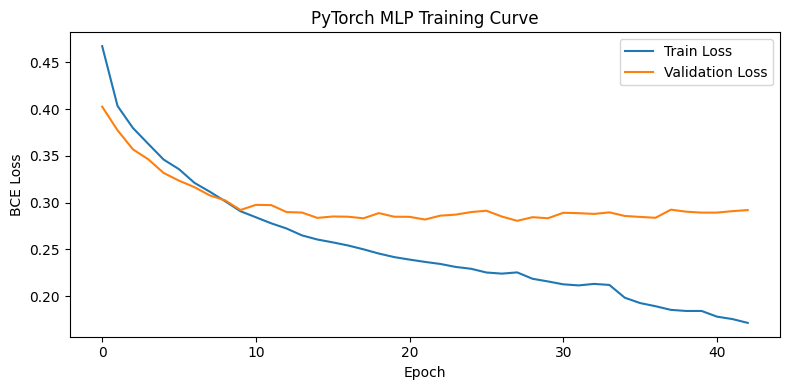

In [10]:
# Plot training curve
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("PyTorch MLP Training Curve")
plt.legend()
plt.tight_layout()
plt.savefig(fig_path / "15_mlp_training_curve.png", dpi=200)
plt.show()

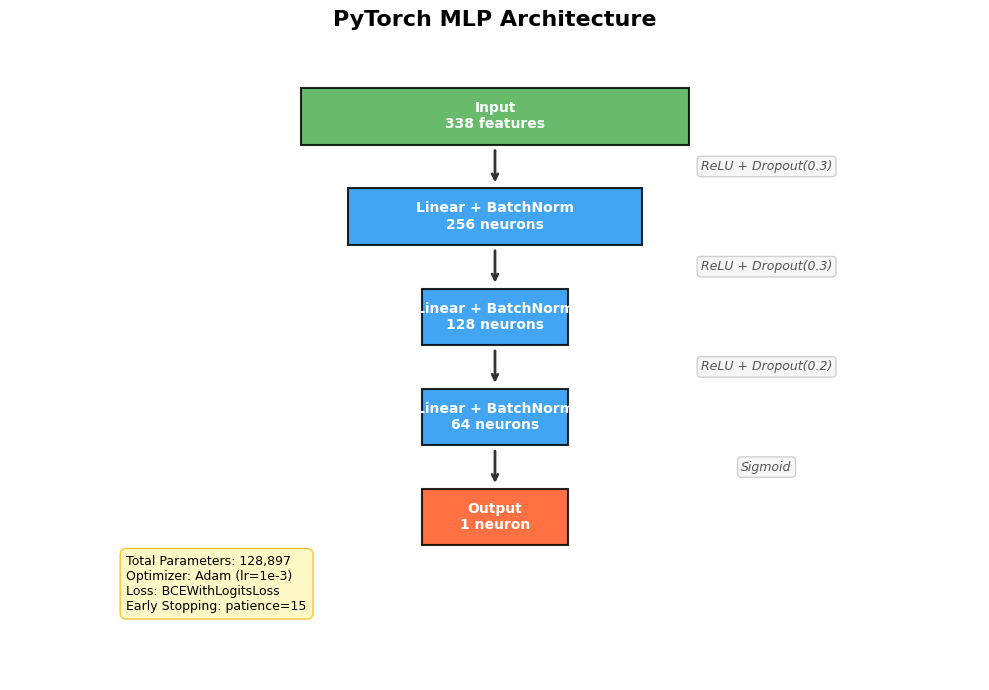

In [11]:
# Visualize MLP architecture
total_params = sum(p.numel() for p in mlp_model.parameters())

fig, ax = plt.subplots(1, 1, figsize=(10, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")
ax.set_title("PyTorch MLP Architecture", fontsize=16, fontweight="bold", pad=20)

# Layer specs: (name, neurons, color, y_position)
layers = [
    (f"Input\n{input_dim} features", input_dim, "#4CAF50", 9.0),
    ("Linear + BatchNorm\n256 neurons", 256, "#2196F3", 7.4),
    ("Linear + BatchNorm\n128 neurons", 128, "#2196F3", 5.8),
    ("Linear + BatchNorm\n64 neurons", 64, "#2196F3", 4.2),
    ("Output\n1 neuron", 1, "#FF5722", 2.6),
]

box_width = 4.0
box_height = 0.9
x_center = 5.0

for i, (name, neurons, color, y) in enumerate(layers):
    # Scale box width by relative neuron count for visual effect
    w = max(1.5, box_width * (neurons / input_dim))
    rect = plt.Rectangle((x_center - w/2, y - box_height/2), w, box_height,
                          facecolor=color, edgecolor="black", linewidth=1.5,
                          alpha=0.85, zorder=2)
    ax.add_patch(rect)
    ax.text(x_center, y, name, ha="center", va="center",
            fontsize=10, fontweight="bold", color="white", zorder=3)

    # Draw arrow to next layer
    if i < len(layers) - 1:
        next_y = layers[i + 1][3]
        ax.annotate("", xy=(x_center, next_y + box_height/2 + 0.05),
                     xytext=(x_center, y - box_height/2 - 0.05),
                     arrowprops=dict(arrowstyle="->", lw=2, color="#333"))

        # Activation / regularization labels between layers
        mid_y = (y + next_y) / 2
        if i < len(layers) - 2:
            dropout = "0.3" if i < 2 else "0.2"
            label = f"ReLU + Dropout({dropout})"
        else:
            label = "Sigmoid"
        ax.text(x_center + 2.8, mid_y, label, ha="center", va="center",
                fontsize=9, fontstyle="italic", color="#555",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="#f5f5f5",
                          edgecolor="#ccc", alpha=0.9))

# Add summary box
summary = (f"Total Parameters: {total_params:,}\n"
           f"Optimizer: Adam (lr=1e-3)\n"
           f"Loss: BCEWithLogitsLoss\n"
           f"Early Stopping: patience=15")
ax.text(1.2, 2.0, summary, ha="left", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#FFF9C4",
                  edgecolor="#FBC02D", alpha=0.95))

plt.tight_layout()
plt.savefig(fig_path / "18_mlp_architecture.png", dpi=200, bbox_inches="tight")
plt.show()

## 9. Evaluate All Models on Test Set

Compare Random Forest (tuned), SVM RBF (tuned), and PyTorch MLP on the held-out test set using accuracy, precision, recall, F1, and ROC-AUC.

In [12]:
def compute_metrics(name, y_true, y_pred, y_score):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
    }

results = []
predictions = {}
scores = {}

# Random Forest
y_pred_rf = best_rf.predict(X_test_processed)
y_score_rf = best_rf.predict_proba(X_test_processed)[:, 1]
results.append(compute_metrics("Random Forest", y_test, y_pred_rf, y_score_rf))
predictions["Random Forest"] = y_pred_rf
scores["Random Forest"] = y_score_rf
print(f"Random Forest  — AUC: {results[-1]['roc_auc']:.4f}, F1: {results[-1]['f1']:.4f}")

# SVM (RBF)
y_pred_svm = best_svm.predict(X_test_processed)
y_score_svm = best_svm.decision_function(X_test_processed)
results.append(compute_metrics("SVM (RBF)", y_test, y_pred_svm, y_score_svm))
predictions["SVM (RBF)"] = y_pred_svm
scores["SVM (RBF)"] = y_score_svm
print(f"SVM (RBF)      — AUC: {results[-1]['roc_auc']:.4f}, F1: {results[-1]['f1']:.4f}")

# PyTorch MLP
mlp_model.eval()
with torch.no_grad():
    y_score_mlp = torch.sigmoid(mlp_model(X_test_t)).numpy().flatten()
y_pred_mlp = (y_score_mlp >= 0.5).astype(int)
results.append(compute_metrics("PyTorch MLP", y_test, y_pred_mlp, y_score_mlp))
predictions["PyTorch MLP"] = y_pred_mlp
scores["PyTorch MLP"] = y_score_mlp
print(f"PyTorch MLP    — AUC: {results[-1]['roc_auc']:.4f}, F1: {results[-1]['f1']:.4f}")

pd.DataFrame(results)

Random Forest  — AUC: 0.9258, F1: 0.7539


SVM (RBF)      — AUC: 0.8920, F1: 0.7147
PyTorch MLP    — AUC: 0.8985, F1: 0.7221


,model,accuracy,precision,recall,f1,roc_auc
0,Random Forest,0.864453,0.759920,0.747899,0.753861,0.925849
1,SVM (RBF),0.834682,0.685909,0.745922,0.714658,0.892024
2,PyTorch MLP,0.848813,0.737005,0.707860,0.722138,0.898523


## 10. Model Comparison

All three tuned models compared on the held-out test set.

In [13]:
model_comparison = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
model_comparison

,model,accuracy,precision,recall,f1,roc_auc
0,Random Forest,0.864453,0.759920,0.747899,0.753861,0.925849
2,PyTorch MLP,0.848813,0.737005,0.707860,0.722138,0.898523
1,SVM (RBF),0.834682,0.685909,0.745922,0.714658,0.892024


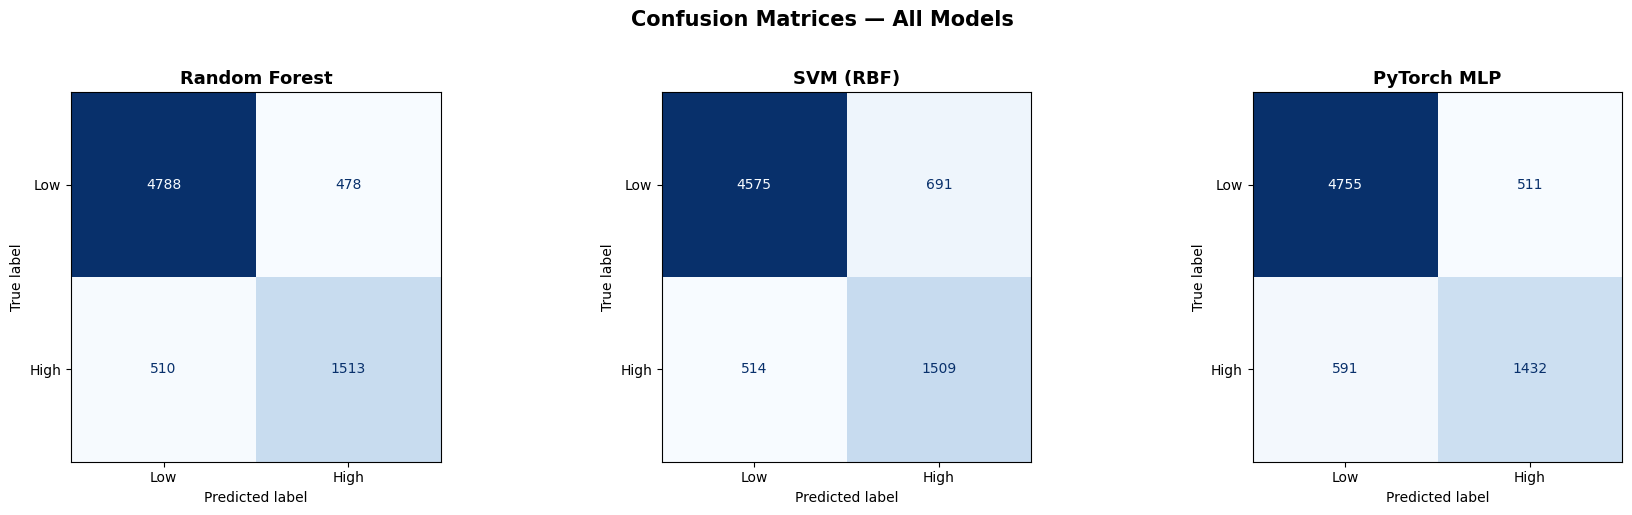

In [14]:
# Confusion matrices for all 3 models side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "High"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name}", fontsize=13, fontweight="bold")

fig.suptitle("Confusion Matrices — All Models", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(fig_path / "19_all_models_confusion_matrices.png", dpi=200, bbox_inches="tight")
plt.show()

/Users/zheweideng/Projects/GR5243_Project4_end_to_end_ml/.venv/lib/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Users/zheweideng/Projects/GR5243_Project4_end_to_end_ml/.venv/lib/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Users/zheweideng/Projects/GR5243_Project4_end_to_end_ml/.venv/lib/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


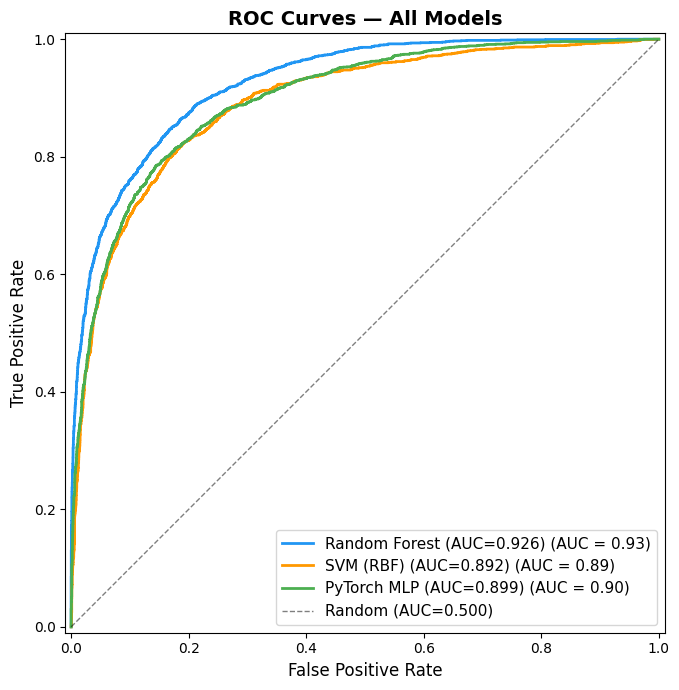

In [15]:
# Overlaid ROC curves for all 3 models
fig, ax = plt.subplots(figsize=(8, 7))

colors = {"Random Forest": "#2196F3", "SVM (RBF)": "#FF9800", "PyTorch MLP": "#4CAF50"}
for name, y_sc in scores.items():
    RocCurveDisplay.from_predictions(
        y_test, y_sc, name=f"{name} (AUC={roc_auc_score(y_test, y_sc):.3f})",
        ax=ax, color=colors[name], lw=2
    )

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random (AUC=0.500)")
ax.set_title("ROC Curves — All Models", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
plt.tight_layout()
plt.savefig(fig_path / "20_all_models_roc_curves.png", dpi=200)
plt.show()

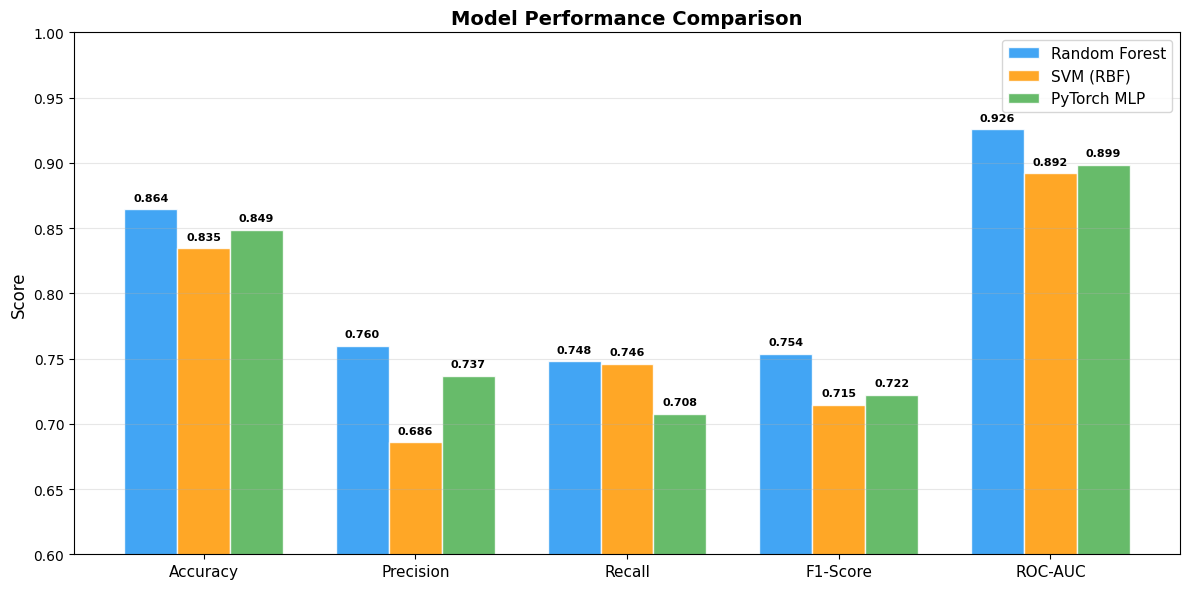

In [16]:
# Grouped bar chart — metric comparison across all models
metrics_to_plot = ["accuracy", "precision", "recall", "f1", "roc_auc"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
model_names = [r["model"] for r in results]
model_colors = ["#2196F3", "#FF9800", "#4CAF50"]

x = np.arange(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
for i, (r, color) in enumerate(zip(results, model_colors)):
    vals = [r[m] for m in metrics_to_plot]
    bars = ax.bar(x + i * width, vals, width, label=r["model"], color=color, alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_ylabel("Score", fontsize=12)
ax.set_title("Model Performance Comparison", fontsize=14, fontweight="bold")
ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0.6, 1.0)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(fig_path / "21_model_metrics_comparison.png", dpi=200)
plt.show()

## 11. Cross-Validation

3-fold stratified cross-validation using `imblearn.pipeline.Pipeline` so that SMOTENC is applied **only inside training folds**, preventing synthetic-sample leakage across CV splits. This produces clean, unbiased CV estimates.

In [17]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Clean CV: SMOTENC applied only inside training folds via imblearn Pipeline
cv_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

cv_pipe = ImbPipeline([
    ("smote", SMOTENC(categorical_features=cat_indices, random_state=42, k_neighbors=5)),
    ("preprocess", cv_preprocessor),
    ("rf", clone(best_rf))
])

print("Cross-validating: Random Forest (clean CV — SMOTENC inside folds)")
scores_cv = cross_validate(
    cv_pipe,
    X_train, y_train,  # Raw data before SMOTENC
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    n_jobs=-1,
)

cv_results = [{
    "model": "Random Forest",
    "cv_accuracy_mean": scores_cv["test_accuracy"].mean(),
    "cv_precision_mean": scores_cv["test_precision"].mean(),
    "cv_recall_mean": scores_cv["test_recall"].mean(),
    "cv_f1_mean": scores_cv["test_f1"].mean(),
    "cv_roc_auc_mean": scores_cv["test_roc_auc"].mean(),
    "cv_roc_auc_std": scores_cv["test_roc_auc"].std(),
}]

cv_comparison = pd.DataFrame(cv_results)
cv_comparison

Cross-validating: Random Forest (clean CV — SMOTENC inside folds)


,model,cv_accuracy_mean,cv_precision_mean,cv_recall_mean,cv_f1_mean,cv_roc_auc_mean,cv_roc_auc_std
0,Random Forest,0.862224,0.752176,0.751174,0.751665,0.920957,0.000863


## 12. Save Model Comparison Tables

In [18]:
model_comparison.to_csv(processed_path / "model_comparison_test_metrics.csv", index=False)
cv_comparison.to_csv(processed_path / "model_comparison_cv_metrics.csv", index=False)

print("Saved model comparison tables to data/processed.")

Saved model comparison tables to data/processed.


## 13. Final Model Selection, Confusion Matrix, and ROC Curve

The final model is selected by ROC-AUC first, then F1-score and interpretability.

In [19]:
final_model_name = model_comparison.iloc[0]["model"]
final_pred = predictions[final_model_name]
final_score = scores[final_model_name]

print("Selected final model:", final_model_name)
print(classification_report(y_test, final_pred, zero_division=0))

Selected final model: Random Forest
              precision    recall  f1-score   support

           0       0.90      0.91      0.91      5266
           1       0.76      0.75      0.75      2023

    accuracy                           0.86      7289
   macro avg       0.83      0.83      0.83      7289
weighted avg       0.86      0.86      0.86      7289



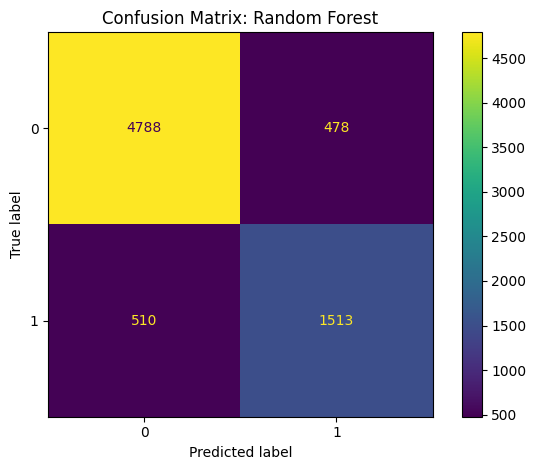

In [20]:
cm = confusion_matrix(y_test, final_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Confusion Matrix: {final_model_name}")
plt.tight_layout()
plt.savefig(fig_path / "12_final_model_confusion_matrix.png", dpi=200)
plt.show()

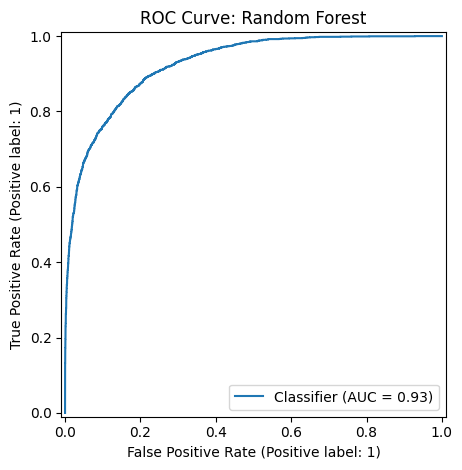

In [21]:
RocCurveDisplay.from_predictions(y_test, final_score)
plt.title(f"ROC Curve: {final_model_name}")
plt.tight_layout()
plt.savefig(fig_path / "13_final_model_roc_curve.png", dpi=200)
plt.show()

## 14. SHAP Values Analysis

SHAP (SHapley Additive exPlanations) quantifies each feature's contribution to individual predictions. We use `TreeExplainer` on the tuned Random Forest model for efficient computation.

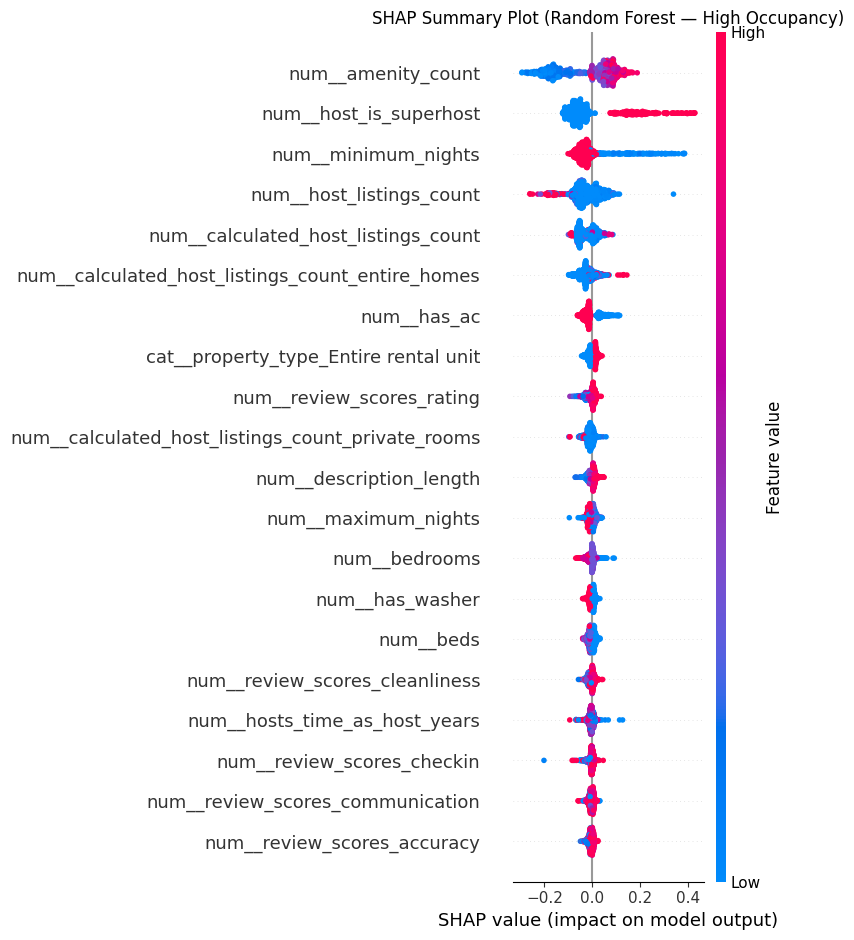

In [22]:
# SHAP analysis using the tuned Random Forest
sample_size = min(1000, X_test_processed.shape[0])
rng = np.random.RandomState(42)
sample_idx = rng.choice(X_test_processed.shape[0], sample_size, replace=False)
X_shap = X_test_processed[sample_idx]

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_shap)

# Handle different SHAP output formats
if isinstance(shap_values, list):
    sv = shap_values[1]
elif shap_values.ndim == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

# SHAP summary beeswarm plot
shap.summary_plot(sv, X_shap, feature_names=feature_names_out, max_display=20, show=False)
plt.title("SHAP Summary Plot (Random Forest — High Occupancy)")
plt.tight_layout()
plt.savefig(fig_path / "16_shap_summary_plot.png", dpi=200, bbox_inches="tight")
plt.show()

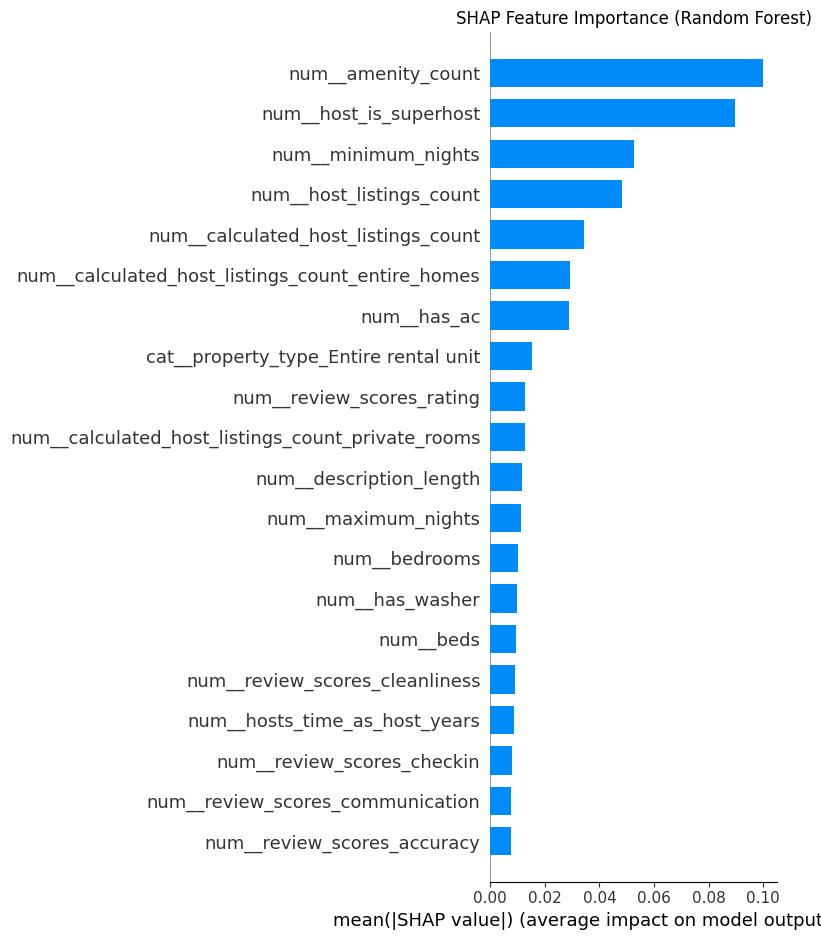

In [23]:
# SHAP bar plot — mean absolute SHAP value per feature
shap.summary_plot(sv, X_shap, feature_names=feature_names_out, plot_type="bar",
                  max_display=20, show=False)
plt.title("SHAP Feature Importance (Random Forest)")
plt.tight_layout()
plt.savefig(fig_path / "17_shap_bar_plot.png", dpi=200, bbox_inches="tight")
plt.show()

## 15. Feature Importance from Random Forest

Gini-based feature importance from the tuned Random Forest, complementing the SHAP analysis above.

In [24]:
importance_df = pd.DataFrame({
    "feature": feature_names_out,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.to_csv(processed_path / "random_forest_feature_importance.csv", index=False)
importance_df.head(20)

,feature,importance
25,num__amenity_count,0.149014
2,num__host_listings_count,0.112190
1,num__host_is_superhost,0.109316
19,num__calculated_host_listings_count,0.073810
10,num__minimum_nights,0.064731
20,num__calculated_host_listings_count_entire_homes,0.043871
21,num__calculated_host_listings_count_private_rooms,0.027134
31,num__description_length,0.026185
0,num__hosts_time_as_host_years,0.025756
12,num__review_scores_rating,0.023985


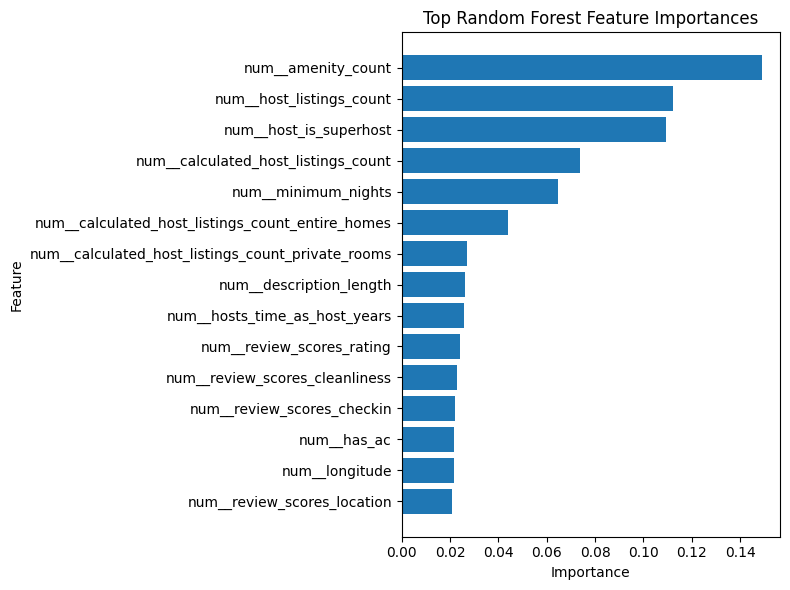

In [25]:
top_features = importance_df.head(15).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(fig_path / "14_random_forest_feature_importance.png", dpi=200)
plt.show()

## 16. Modeling Summary

Main takeaways:

1. We applied SMOTENC once to create balanced training data, shared across all models.
2. We removed post-outcome proxy variables to prevent data leakage.
3. Hyperparameter tuning via `RandomizedSearchCV` improved Random Forest and SVM performance.
4. Three models compared: Random Forest (tuned), SVM with RBF kernel (tuned), PyTorch MLP (4-layer network).
5. SHAP values provided feature-level interpretability for the Random Forest model.
6. The final model was selected based on ROC-AUC and overall predictive performance.